# Notebook 7 — SHAP Explainability

This notebook explains the final tuned model's predictions using SHAP
(SHapley Additive exPlanations), covering global feature importance and
individual prediction breakdowns.

## 1. Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

shap.initjs()

c:\Users\arushi khare\OneDrive\Desktop\Flight-Price-Prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset & Recreate Split

Same random_state as Notebooks 5 and 6 to keep test data consistent.

In [2]:
DATA_DIR = Path("../data/processed")
df = pd.read_csv(DATA_DIR / "featured_train.csv")

X = df.drop(columns=["Price"])
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Test set shape: {X_test.shape}")

Test set shape: (2093, 12)


## 3. Load Final Tuned Model

In [3]:
MODEL_DIR = Path("../models")
model_pipeline = joblib.load(MODEL_DIR / "final_tuned_model.pkl")

preprocessor = model_pipeline.named_steps["preprocessor"]
model = model_pipeline.named_steps["model"]

print(f"Loaded model: {type(model).__name__}")

Loaded model: XGBRegressor


## 4. Transform Test Data Through Preprocessor

SHAP needs the fully numeric, encoded feature matrix — not the raw
DataFrame — since it explains the model, not the pipeline.

In [4]:
X_test_transformed = preprocessor.transform(X_test)

# Recover readable feature names after encoding
feature_names = preprocessor.get_feature_names_out()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index,
)

print(f"Transformed shape: {X_test_transformed_df.shape}")
X_test_transformed_df.head()

Transformed shape: (2093, 32)


,categorical__Airline_Air Asia,categorical__Airline_Air India,categorical__Airline_GoAir,categorical__Airline_IndiGo,categorical__Airline_Jet Airways,categorical__Airline_Jet Airways Business,categorical__Airline_Multiple carriers,categorical__Airline_Multiple carriers Premium economy,categorical__Airline_SpiceJet,categorical__Airline_Trujet,...,categorical__Destination_New Delhi,remainder__Total_Stops,remainder__Journey_Day,remainder__Journey_Month,remainder__Journey_Weekday,remainder__Departure_Hour,remainder__Departure_Minute,remainder__Arrival_Hour,remainder__Arrival_Minute,remainder__Duration_Minutes
2138,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,6.0,3.0,2.0,8.0,0.0,8.0,15.0,1455.0
3749,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,6.0,6.0,3.0,22.0,20.0,0.0,40.0,140.0
713,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,18.0,3.0,0.0,5.0,30.0,8.0,20.0,170.0
7459,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,24.0,3.0,6.0,15.0,50.0,17.0,20.0,90.0
7316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,27.0,4.0,5.0,9.0,30.0,12.0,20.0,170.0


## 5. Create SHAP Explainer

Uses TreeExplainer since all top-performing candidates
(RandomForest, XGBoost, LightGBM, CatBoost, GradientBoosting, ExtraTrees)
are tree-based models.

In [5]:
explainer = shap.TreeExplainer(model)

# Use a sample for speed if the test set is large
SAMPLE_SIZE = min(500, len(X_test_transformed_df))
X_sample = X_test_transformed_df.sample(SAMPLE_SIZE, random_state=42)

shap_values = explainer.shap_values(X_sample)

print(f"SHAP values computed for {SAMPLE_SIZE} samples.")

SHAP values computed for 500 samples.


## 6. Global Feature Importance — Summary Plot

Shows which features matter most across all predictions, and whether
high/low values push price up or down.

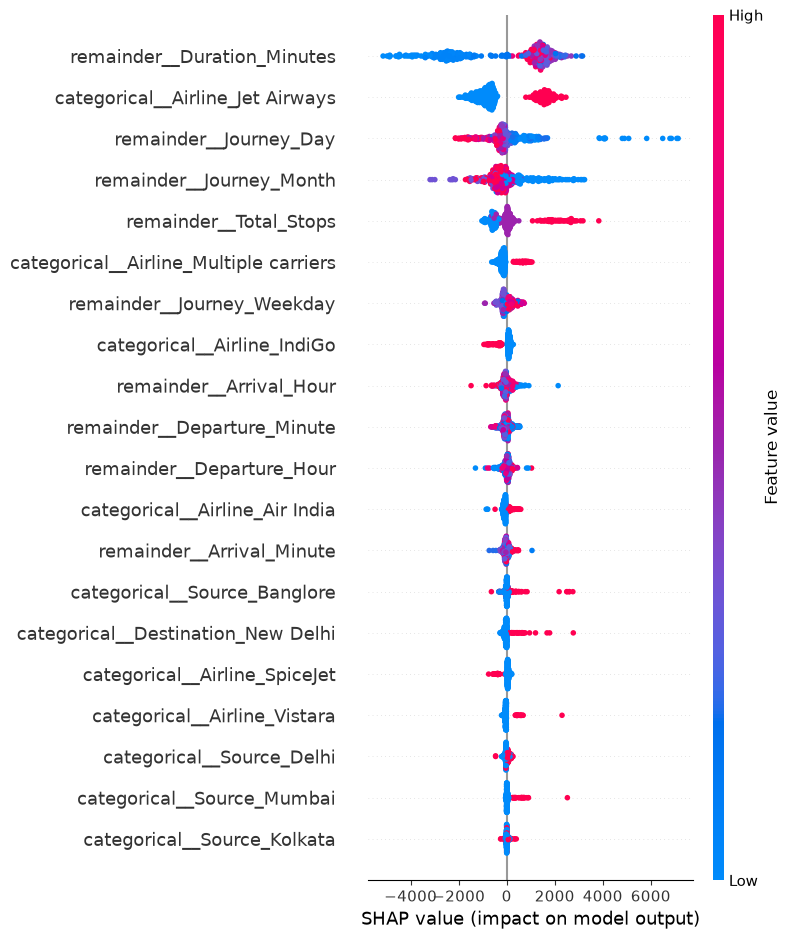

In [6]:
SCREENSHOTS_DIR = Path("../screenshots")
SCREENSHOTS_DIR.mkdir(parents=True, exist_ok=True)

plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig(SCREENSHOTS_DIR / "shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Feature Importance — Bar Plot (Top 20)

A simpler, ranked view for the README.

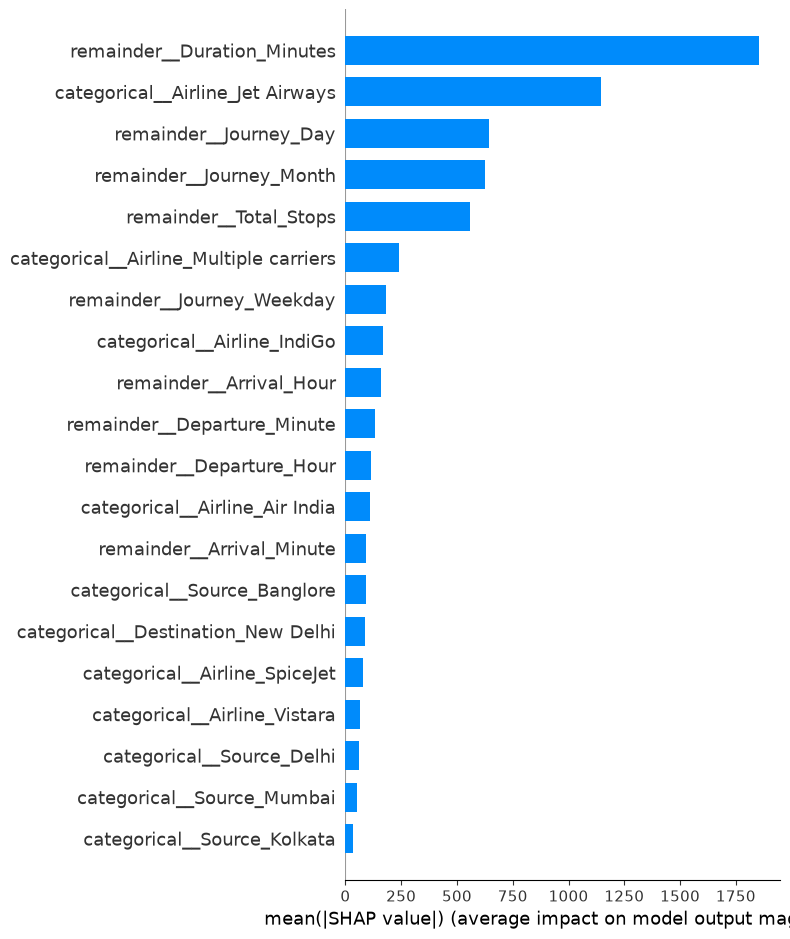

In [7]:
plt.figure()
shap.summary_plot(
    shap_values, X_sample,
    plot_type="bar",
    max_display=20,
    show=False,
)
plt.tight_layout()
plt.savefig(SCREENSHOTS_DIR / "shap_feature_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Explain a Single Prediction

Pick one test sample and break down exactly why the model predicted
that specific price.

In [8]:
sample_index = 0

sample_row = X_sample.iloc[[sample_index]]
predicted_price = model.predict(sample_row)[0]
actual_price = y_test.loc[sample_row.index[0]]

print(f"Predicted Price : ₹{predicted_price:,.2f}")
print(f"Actual Price    : ₹{actual_price:,.2f}")

Predicted Price : ₹5,830.17
Actual Price    : ₹6,151.00


## 9. Waterfall Plot for the Single Prediction

Shows exactly how each feature pushed the prediction up or down from
the baseline (average predicted price).

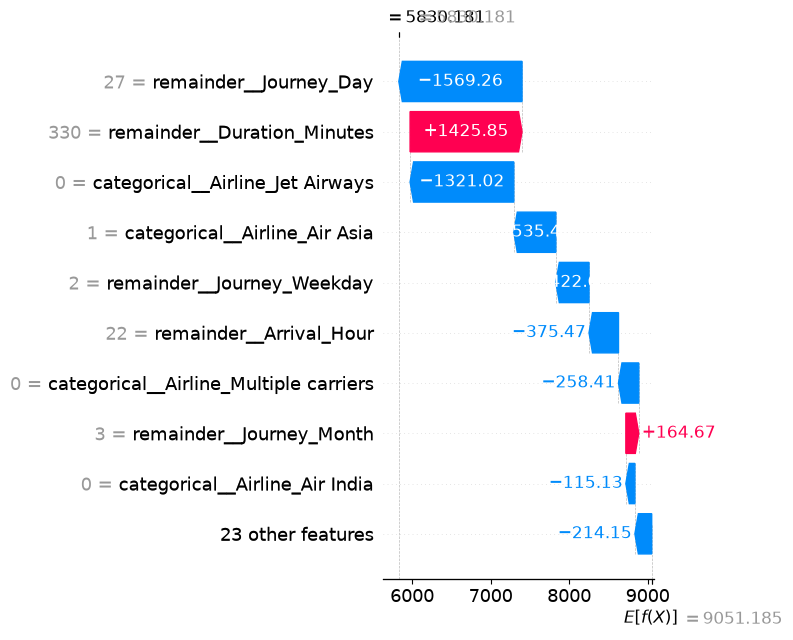

In [9]:
explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=sample_row.values[0],
    feature_names=X_sample.columns.tolist(),
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig(SCREENSHOTS_DIR / "shap_waterfall_single_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Save Top Features to CSV

For quick reference in the README without re-running SHAP.

In [10]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "Feature": X_sample.columns,
    "Mean |SHAP Value|": mean_abs_shap,
}).sort_values(by="Mean |SHAP Value|", ascending=False).reset_index(drop=True)

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

feature_importance_df.to_csv(
    RESULTS_DIR / "shap_feature_importance.csv", index=False
)

print("Top 10 Most Important Features:")
feature_importance_df.head(10)

Top 10 Most Important Features:


,Feature,Mean |SHAP Value|
0,remainder__Duration_Minutes,1855.021484
1,categorical__Airline_Jet Airways,1147.758789
2,remainder__Journey_Day,642.834167
3,remainder__Journey_Month,625.062195
4,remainder__Total_Stops,557.993225
5,categorical__Airline_Multiple carriers,241.904495
6,remainder__Journey_Weekday,180.053329
7,categorical__Airline_IndiGo,170.264160
8,remainder__Arrival_Hour,158.864365
9,remainder__Departure_Minute,131.124115
